Se comienza cargando los datos

In [ ]:
import pandas as pd
import os
import re

from google.colab import drive
drive.mount('/content/drive')

ruta_data = './data/XFLR5_Data' 
ruta_geometria = './data/XFLR5_Geometry'

Mounted at /content/drive


Automatizamos la carga, limpieza y estructuración de los datos, pasando de todos los archivos CSV a un unico DataFrame plano.

In [2]:
def procesar_csvs_xflr5_seguro(ruta_carpeta):
    datos_completos = []
    
    # 1. Comprobación de ruta
    if not os.path.exists(ruta_carpeta):
        print(f"ERROR: No se encuentra la carpeta '{ruta_carpeta}'")
        return None

    for archivo in os.listdir(ruta_carpeta):
        if not archivo.endswith(".csv"):
            continue
            
        ruta_completa = os.path.join(ruta_carpeta, archivo)
        
        match = re.search(r'Re_([\d\.]+)_(\d+)', archivo)
        if not match:
            print(f"Aviso: Saltando '{archivo}' (no cumple el formato Re_X.X_Y)")
            continue
            
        reynolds = float(match.group(1)) * 1e6
        delta = float(match.group(2))
        
        with open(ruta_completa, 'r') as f:
            lineas = f.readlines()
            
        i = 0
        current_alpha = current_cd = current_cl = current_cm = None
        
        while i < len(lineas):
            linea = lineas[i].strip()
            
            try:
                # Extraer variables globales
                if linea.startswith("Alpha"):
                    i += 1
                    valores = lineas[i].strip().split(',')
                    if len(valores) >= 4:
                        current_alpha = float(valores[0])
                        current_cd    = float(valores[1])
                        current_cl    = float(valores[2])
                        current_cm    = float(valores[3])
                    i += 1
                    continue
                    
                if linea.startswith("Cpi,Cpv"):
                    i += 1
                    point_idx = 0
                    while i < len(lineas) and lineas[i].strip() != "" and not lineas[i].startswith("Reynolds"):
                        cp_vals = lineas[i].strip().split(',')
                        
                        # Nos aseguramos de que realmente hay 2 valores y no es texto basura
                        if len(cp_vals) >= 2 and cp_vals[0].replace('.','',1).replace('-','',1).isdigit():
                            datos_completos.append({
                                'Reynolds': reynolds,
                                'Delta': delta,
                                'Alpha': current_alpha,
                                'Cl': current_cl,
                                'Cd': current_cd,
                                'Cm': current_cm,
                                'Point_Index': point_idx,
                                'Cpi': float(cp_vals[0]),
                                'Cpv': float(cp_vals[1])
                            })
                            point_idx += 1
                        i += 1
                    continue
                    
            except Exception as e:
                # 3. Captura del error exacto
                print(f"ERROR CRÍTICO en archivo: {archivo}")
                print(f"   Línea {i+1}: '{lineas[i].strip()}'")
                print(f"   Tipo de error: {e}")
                return None  # Detenemos la ejecución para que puedas leer el error
                
            i += 1
            
    print(f"¡Éxito! Se han procesado {len(datos_completos)} puntos de datos.")
    return pd.DataFrame(datos_completos)


df = procesar_csvs_xflr5_seguro(ruta_data)


¡Éxito! Se han procesado 370516 puntos de datos.


In [3]:
#Visualización del dataframe
df.head()

,Reynolds,Delta,Alpha,Cl,Cd,Cm,Point_Index,Cpi,Cpv
0,900000.0,12.0,-15.0,-0.551,0.022,-0.168,0,0.4256,0.1854
1,900000.0,12.0,-15.0,-0.551,0.022,-0.168,1,0.2438,0.1579
2,900000.0,12.0,-15.0,-0.551,0.022,-0.168,2,0.1693,0.1129
3,900000.0,12.0,-15.0,-0.551,0.022,-0.168,3,0.1073,0.0695
4,900000.0,12.0,-15.0,-0.551,0.022,-0.168,4,0.0560,0.0293


Lectura y estructuración de los archivos de coordenadas que definen la geometría física de los perfiles aerodinámicos.

In [ ]:
def cargar_todas_las_geometrias(ruta_carpeta_dats):

    diccionario_geometrias = {}
    
    for archivo in os.listdir(ruta_carpeta_dats):
        if archivo.endswith('.dat'):
            ruta_completa = os.path.join(ruta_carpeta_dats, archivo)
            
            # Extraemos el identificador del archivo (ej: de 'airfoil_00.dat' sacamos '00')
            identificador = archivo.split('_')[1].split('.')[0]
            
            # Cargamos el DAT
            df_coords = pd.read_csv(ruta_completa, sep='\s+', skiprows=1, names=['X', 'Y'])
            df_coords = df_coords.reset_index().rename(columns={'index': 'Point_Index'})
            
            diccionario_geometrias[identificador] = df_coords
            
    print(f"Se han cargado {len(diccionario_geometrias)} geometrías distintas.")
    return diccionario_geometrias

geometrias = cargar_todas_las_geometrias(ruta_geometria)

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4123/464959893.py:13: SyntaxWarning: invalid escape sequence '\s'
  df_coords = pd.read_csv(ruta_completa, sep='\s+', skiprows=1, names=['X', 'Y'])


Se han cargado 11 geometrías distintas.


In [5]:
angulos_flap = df['Alpha'].unique()
angulos_flap.sort()

print(f"He encontrado {len(angulos_flap)} ángulos de flap diferentes:")
print(angulos_flap)

He encontrado 36 ángulos de flap diferentes:
[-15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.
  -1.   0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.
  13.  14.  15.  16.  17.  18.  19.  20.]


In [6]:
mapa_flaps = {
    0.0: 'airfoil_00.dat',
    3.0: 'airfoil_03.dat',
    6.0: 'airfoil_06.dat',
    9.0: 'airfoil_09.dat',
    12.0: 'airfoil_12.dat',
    15.0: 'airfoil_15.dat',
    18.0: 'airfoil_18.dat',
    21.0: 'airfoil_21.dat',
    24.0: 'airfoil_24.dat',
    27.0: 'airfoil_27.dat',
    30.0: 'airfoil_30.dat'
}

Fusión del dominio aerodinámico con el espacial

In [7]:
def cruce_final_optimizado(df_presiones, diccionario_geometrias):
    frames_cruzados = []
    
    # Agrupamos por ángulo de flap (Delta)
    for delta, df_grupo in df_presiones.groupby('Delta'):
        
        identificador = f"{int(delta):02d}" 
        
        # Verificamos si esa geometría existe en tu memoria
        if identificador in diccionario_geometrias:
            # 1. Sacamos las coordenadas de la RAM (¡Instantáneo!)
            df_coords = diccionario_geometrias[identificador]
            
            # 2. Cruzamos los datos
            grupo_cruzado = pd.merge(df_grupo, df_coords, on='Point_Index', how='inner')
            frames_cruzados.append(grupo_cruzado)
        else:
            print(f"Aviso: No se encontró geometría para Delta = {delta} (buscando '{identificador}')")
            
    # Juntamos todo en el dataset final
    df_final = pd.concat(frames_cruzados, ignore_index=True)
    
    # Ordenamos las columnas
    columnas_ordenadas = ['Reynolds', 'Delta', 'Alpha', 'Point_Index', 'X', 'Y', 'Cpi', 'Cpv', 'Cl', 'Cd', 'Cm']
    columnas_presentes = [col for col in columnas_ordenadas if col in df_final.columns]
    
    return df_final[columnas_presentes]

df_dataset = cruce_final_optimizado(df, geometrias)

print(f"Dataset final creado con {df_dataset.shape[0]} filas.")
df_dataset.head()

Dataset final creado con 370516 filas.


,Reynolds,Delta,Alpha,Point_Index,X,Y,Cpi,Cpv,Cl,Cd,Cm
0,900000.0,0.0,-15.0,0,1.000000,0.001260,0.4425,-0.1159,-1.045,0.058,-0.05
1,900000.0,0.0,-15.0,1,0.992801,0.002743,0.3005,-0.0948,-1.045,0.058,-0.05
2,900000.0,0.0,-15.0,2,0.979889,0.005365,0.2534,-0.0897,-1.045,0.058,-0.05
3,900000.0,0.0,-15.0,3,0.963518,0.008624,0.2210,-0.0828,-1.045,0.058,-0.05
4,900000.0,0.0,-15.0,4,0.944547,0.012309,0.1994,-0.0765,-1.045,0.058,-0.05


Preparación de los datos de entrada y salida para alimentar la red neuronal

División del dataset

Escalado de las variables

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# 1. Separar Variables de Entrada (Features) y Variable Objetivo (Target)
columnas_entrada = ['Reynolds', 'Delta', 'Alpha', 'X', 'Y']
X_crudo = df_dataset[columnas_entrada].values
y_crudo = df_dataset[['Cpi']].values # Cambia a 'Cpv' si prefieres el viscoso

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_crudo, y_crudo, test_size=0.2, random_state=42)

# 3. Escalado (Normalización) de las variables de entrada
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Escalado de la variable de salida (Cp). 
# El Cp suele estar entre -5 y +1, pero escalarlo ayuda a la red a converger más rápido.
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 4. Convertir las matrices de NumPy a Tensores de PyTorch (El formato que usa la red)
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

print(f"Datos listos para la Red Neuronal.")
print(f"Dimensiones de Entrenamiento (X): {X_train_tensor.shape}")
print(f"Dimensiones de Prueba (X): {X_test_tensor.shape}")

Datos listos para la Red Neuronal.
Dimensiones de Entrenamiento (X): torch.Size([296412, 5])
Dimensiones de Prueba (X): torch.Size([74104, 5])


Definición de la red neuronal y entrenamiento

Iniciando motor en: CUDA
Comenzando entrenamiento (Backpropagation)...
Época 050/500 | Error Train: 0.0266 | Error Test: 0.0270
Época 100/500 | Error Train: 0.0143 | Error Test: 0.0170
Época 150/500 | Error Train: 0.0062 | Error Test: 0.0073
Época 200/500 | Error Train: 0.0034 | Error Test: 0.0034
Época 250/500 | Error Train: 0.0026 | Error Test: 0.0026
Época 300/500 | Error Train: 0.0022 | Error Test: 0.0025
Época 350/500 | Error Train: 0.0018 | Error Test: 0.0018
Época 400/500 | Error Train: 0.0018 | Error Test: 0.0017
Época 450/500 | Error Train: 0.0013 | Error Test: 0.0013
Época 500/500 | Error Train: 0.0033 | Error Test: 0.0014
¡Entrenamiento completado!


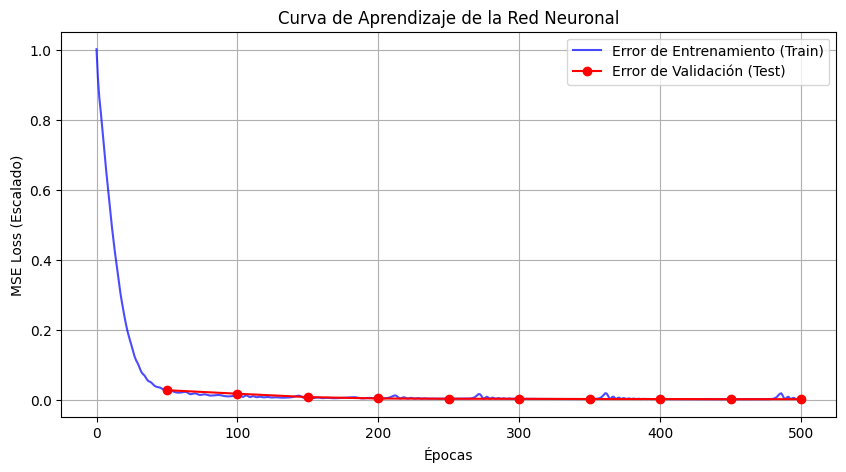

In [9]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Detección automática de Hardware (Usa la GPU si existe, si no, la CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Iniciando motor en: {device.type.upper()}")

# Movemos los tensores a la memoria del dispositivo correspondiente
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor  = X_test_tensor.to(device)
y_test_tensor  = y_test_tensor.to(device)

# 2. Definición de la Arquitectura (Perceptrón Multicapa - MLP)
class SurrogateAirfoilModel(nn.Module):
    def __init__(self):
        super(SurrogateAirfoilModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(5, 64),    # Capa de Entrada: 5 variables
            nn.ReLU(),           # Función de activación no lineal
            nn.Linear(64, 128),  # Capa Oculta 1: Expandimos características
            nn.ReLU(),
            nn.Linear(128, 64),  # Capa Oculta 2: Comprimimos información
            nn.ReLU(),
            nn.Linear(64, 1)     # Capa de Salida: 1 variable (Cpi escalado)
        )

    def forward(self, x):
        return self.network(x)

modelo = SurrogateAirfoilModel().to(device)

# 3. Configuración del Entrenamiento
criterio = nn.MSELoss() # Error Cuadrático Medio
optimizador = optim.Adam(modelo.parameters(), lr=0.005) # Algoritmo de descenso de gradiente

epocas = 500
historial_train = []
historial_test = []

print("Comenzando entrenamiento (Backpropagation)...")
# 4. El Bucle de Entrenamiento
for epoca in range(epocas):
    #ENTRENAMIENTO
    modelo.train()
    optimizador.zero_grad() # Reseteamos gradientes
    
    predicciones = modelo(X_train_tensor) # La IA intenta adivinar
    perdida = criterio(predicciones, y_train_tensor) # Calculamos su error
    
    perdida.backward() # Propagación hacia atrás (Aprende de sus errores)
    optimizador.step() # Actualiza las matemáticas internas
    
    historial_train.append(perdida.item())
    
    #EVALUACIÓN
    if (epoca + 1) % 50 == 0:
        modelo.eval() # Congelamos el aprendizaje
        with torch.no_grad():
            pred_test = modelo(X_test_tensor)
            perdida_test = criterio(pred_test, y_test_tensor)
            historial_test.append(perdida_test.item())
            
        print(f"Época {epoca+1:03d}/{epocas} | Error Train: {perdida.item():.4f} | Error Test: {perdida_test.item():.4f}")

print("¡Entrenamiento completado!")

# 5. Visualización del Aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(historial_train, label='Error de Entrenamiento (Train)', color='blue', alpha=0.7)
# Como el test se guarda cada 50 épocas, ajustamos el eje X para el gráfico
eje_x_test = [i * 50 for i in range(1, len(historial_test) + 1)]
plt.plot(eje_x_test, historial_test, label='Error de Validación (Test)', color='red', marker='o')

plt.title('Curva de Aprendizaje de la Red Neuronal')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Escalado)')
plt.legend()
plt.grid(True)
plt.show()

Visualización de resultados

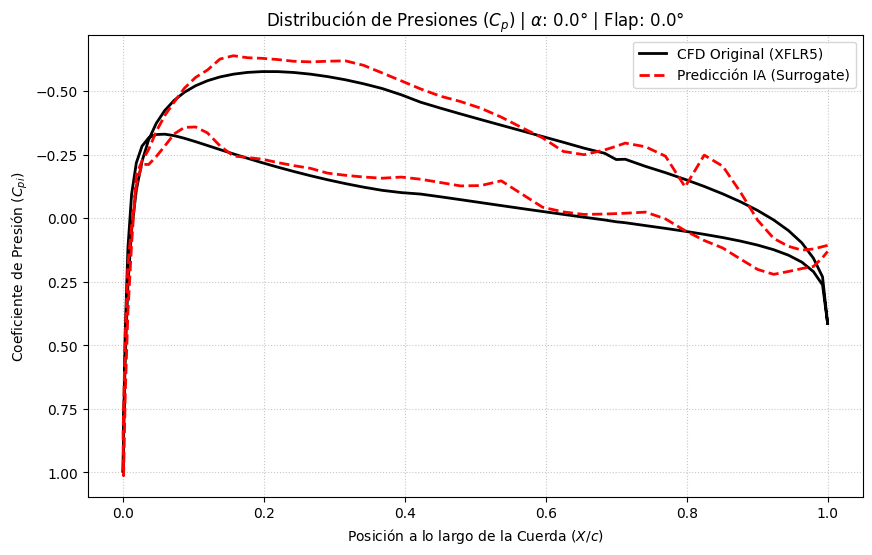

In [10]:
import numpy as np

alfa_prueba = 0.0
delta_prueba = 0.0
reynolds_prueba = 900000.0

condicion = (df_dataset['Alpha'] == alfa_prueba) & \
            (df_dataset['Delta'] == delta_prueba) & \
            (df_dataset['Reynolds'] == reynolds_prueba)

datos_reales = df_dataset[condicion].sort_values(by='Point_Index')

if len(datos_reales) == 0:
    print(f"Aviso: No encontré simulaciones para Alpha={alfa_prueba} y Delta={delta_prueba}.")
else:
    X_real = datos_reales['X'].values
    Cpi_real = datos_reales['Cpi'].values
    
    entradas = datos_reales[['Reynolds', 'Delta', 'Alpha', 'X', 'Y']].values
    entradas_escaladas = scaler_X.transform(entradas)
    entradas_tensor = torch.FloatTensor(entradas_escaladas).to(device)
    
    modelo.eval()
    with torch.no_grad():
        prediccion_escalada = modelo(entradas_tensor).cpu().numpy()
        
    Cpi_predicho = scaler_y.inverse_transform(prediccion_escalada)
    
    plt.figure(figsize=(10, 6))
    
    # Dibujamos las curvas
    plt.plot(X_real, Cpi_real, 'k-', linewidth=2, label='CFD Original (XFLR5)')
    plt.plot(X_real, Cpi_predicho, 'r--', linewidth=2, label='Predicción IA (Surrogate)')
    
    plt.gca().invert_yaxis()
    plt.title(f'Distribución de Presiones ($C_p$) | $\\alpha$: {alfa_prueba}° | Flap: {delta_prueba}°')
    plt.xlabel('Posición a lo largo de la Cuerda ($X/c$)')
    plt.ylabel('Coeficiente de Presión ($C_{pi}$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

Con el objetivo de mejorar la precisión sustituimos ReLu por GELU y añadimos Weight Decay. Se busca erradicar las discontinuidades matemáticas y el ruido.

In [11]:
class SurrogateAirfoilSmooth(nn.Module):
    def __init__(self):
        super(SurrogateAirfoilSmooth, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(5, 128),   # Más ancha
            nn.GELU(),           
            nn.Linear(128, 256), # Capa profunda más grande
            nn.GELU(),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

modelo_suave = SurrogateAirfoilSmooth().to(device)

# lr más bajito (0.001) para que aprenda los detalles finos sin saltar
criterio = nn.MSELoss()
optimizador_suave = optim.Adam(modelo_suave.parameters(), lr=0.001, weight_decay=1e-5)

# 3. Entrenamiento (lo haremos un poco más largo, 800 épocas, ya que el lr es menor)
epocas = 800
print("Entrenando modelo suave (GELU + Weight Decay)...")

for epoca in range(epocas):
    modelo_suave.train()
    optimizador_suave.zero_grad()
    
    predicciones = modelo_suave(X_train_tensor)
    perdida = criterio(predicciones, y_train_tensor)
    
    perdida.backward()
    optimizador_suave.step()
    
    if (epoca + 1) % 100 == 0:
        modelo_suave.eval()
        with torch.no_grad():
            pred_test = modelo_suave(X_test_tensor)
            perdida_test = criterio(pred_test, y_test_tensor)
        print(f"Época {epoca+1:03d}/{epocas} | Error Test: {perdida_test.item():.5f}")

print("¡Entrenamiento completado!")

Entrenando modelo suave (GELU + Weight Decay)...
Época 100/800 | Error Test: 0.03727
Época 200/800 | Error Test: 0.00700
Época 300/800 | Error Test: 0.00402
Época 400/800 | Error Test: 0.00264
Época 500/800 | Error Test: 0.00192
Época 600/800 | Error Test: 0.00144
Época 700/800 | Error Test: 0.00120
Época 800/800 | Error Test: 0.00107
¡Entrenamiento completado!


Visualizamos los nuevos resultados

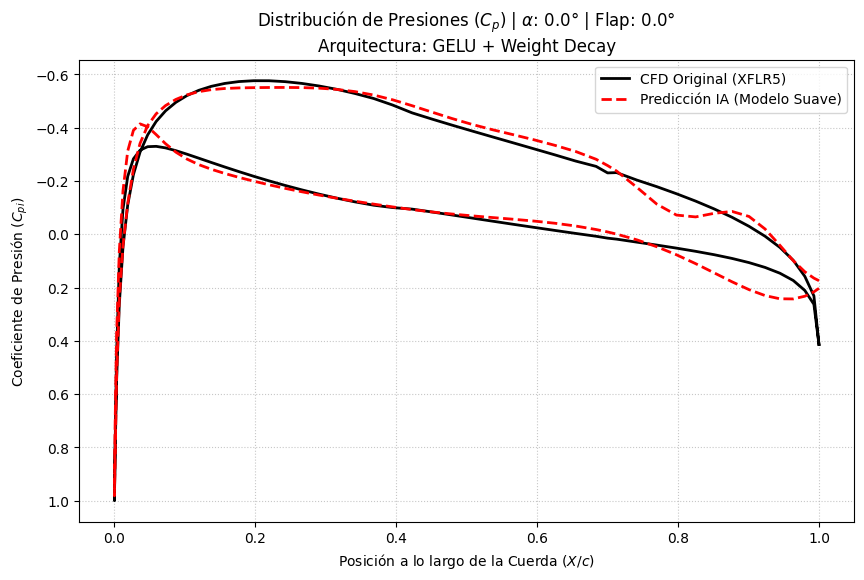

In [12]:
alfa_prueba = 0.0
delta_prueba = 0.0
reynolds_prueba = 900000.0

condicion = (df_dataset['Alpha'] == alfa_prueba) & \
            (df_dataset['Delta'] == delta_prueba) & \
            (df_dataset['Reynolds'] == reynolds_prueba)

# Ordenamos por el índice espacial
datos_reales = df_dataset[condicion].sort_values(by='Point_Index')

if len(datos_reales) == 0:
    print(f"Aviso: No encontré simulaciones para Alpha={alfa_prueba} y Delta={delta_prueba}.")
else:
    X_real = datos_reales['X'].values
    Cpi_real = datos_reales['Cpi'].values
    
    entradas = datos_reales[['Reynolds', 'Delta', 'Alpha', 'X', 'Y']].values
    entradas_escaladas = scaler_X.transform(entradas)
    entradas_tensor = torch.FloatTensor(entradas_escaladas).to(device)
    
    # USAMOS EL MODELO SUAVE
    modelo_suave.eval()
    with torch.no_grad():
        prediccion_escalada = modelo_suave(entradas_tensor).cpu().numpy()
        
    Cpi_predicho = scaler_y.inverse_transform(prediccion_escalada)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(X_real, Cpi_real, 'k-', linewidth=2, label='CFD Original (XFLR5)')
    # Añadimos un pequeño suavizado extra en la visualización
    plt.plot(X_real, Cpi_predicho, 'r--', linewidth=2, label='Predicción IA (Modelo Suave)')
    
    plt.gca().invert_yaxis()
    plt.title(f'Distribución de Presiones ($C_p$) | $\\alpha$: {alfa_prueba}° | Flap: {delta_prueba}°\nArquitectura: GELU + Weight Decay')
    plt.xlabel('Posición a lo largo de la Cuerda ($X/c$)')
    plt.ylabel('Coeficiente de Presión ($C_{pi}$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

In [13]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.0 MB/s eta 0:00:00


Introducimos un procesamiento por lotes mediante Dataloaders.

Optimización bayesiana para encontrar la arquitactura y parametros de regularización óptimos

In [14]:
import optuna
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Empaquetar los datos en DataLoaders (Mini-batches de 2048 filas)
# Esto es CRÍTICO para que la red capte los detalles finos de la presión
batch_size = 2048
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [15]:
# 2. Definir la Función Objetivo para Optuna
def objective(trial):
    # --- Espacio de Búsqueda de Hiperparámetros ---
    # ¿Cuántas capas ocultas? (De 2 a 5)
    n_layers = trial.suggest_int('n_layers', 2, 5)
    # ¿Tasa de aprendizaje? (Búsqueda logarítmica)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    # ¿Penalización de peso (Weight Decay)?
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    
    # --- Construcción Dinámica del Modelo ---
    layers = []
    in_features = 5 # Siempre empezamos con 5 variables
    
    for i in range(n_layers):
        # ¿Cuántas neuronas en esta capa? (De 64 a 512, en múltiplos de 64)
        out_features = trial.suggest_int(f'n_units_l{i}', 64, 512, step=64)
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.GELU()) # Mantenemos GELU para que sea suave
        in_features = out_features
        
    layers.append(nn.Linear(in_features, 1)) # Capa de salida
    modelo_opt = nn.Sequential(*layers).to(device)
    
    # --- Configuración del Entrenamiento Corto ---
    criterio = nn.MSELoss()
    optimizador = optim.Adam(modelo_opt.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Entrenamos solo 30 épocas para evaluar rápido si la arquitectura es buena
    epocas_prueba = 30
    
    for epoca in range(epocas_prueba):
        modelo_opt.train()
        for batch_X, batch_y in train_loader:
            optimizador.zero_grad()
            predicciones = modelo_opt(batch_X)
            perdida = criterio(predicciones, batch_y)
            perdida.backward()
            optimizador.step()
            
    # --- Evaluación Final del Trial ---
    modelo_opt.eval()
    perdida_test_total = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            pred_test = modelo_opt(batch_X)
            perdida_test_total += criterio(pred_test, batch_y).item()
            
    # Devolvemos el error promedio de este ensayo
    return perdida_test_total / len(test_loader)

# 3. Lanzar la Optimización
print("Iniciando la cacería de hiperparámetros con Optuna...")
# Queremos minimizar el error
estudio = optuna.create_study(direction='minimize')
# Haremos 20 ensayos diferentes (puedes subirlo a 50 si tienes tiempo)
estudio.optimize(objective, n_trials=20)

print("\n¡Búsqueda completada!")
print("Los mejores hiperparámetros encontrados son:")
for key, value in estudio.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-06-03 18:48:39,903] A new study created in memory with name: no-name-3cdb4aec-df59-4205-a112-fb30f4c67643


Iniciando la cacería de hiperparámetros con Optuna...


[I 2026-06-03 18:50:03,232] Trial 0 finished with value: 0.0020897895053683503 and parameters: {'n_layers': 3, 'lr': 0.0018375054411691534, 'weight_decay': 0.00044459713703757, 'n_units_l0': 384, 'n_units_l1': 64, 'n_units_l2': 384}. Best is trial 0 with value: 0.0020897895053683503.
[I 2026-06-03 18:51:24,218] Trial 1 finished with value: 0.003284043978547325 and parameters: {'n_layers': 2, 'lr': 0.002288947919969185, 'weight_decay': 0.00022652988750258948, 'n_units_l0': 256, 'n_units_l1': 448}. Best is trial 0 with value: 0.0020897895053683503.
[I 2026-06-03 18:52:45,536] Trial 2 finished with value: 0.004832306203457552 and parameters: {'n_layers': 2, 'lr': 0.00019850662331389845, 'weight_decay': 1.5143883881095274e-06, 'n_units_l0': 64, 'n_units_l1': 512}. Best is trial 0 with value: 0.0020897895053683503.
[I 2026-06-03 18:54:05,998] Trial 3 finished with value: 0.0014652264858218463 and parameters: {'n_layers': 2, 'lr': 0.0002988007277898381, 'weight_decay': 4.779043928787015e-05,


¡Búsqueda completada!
Los mejores hiperparámetros encontrados son:
  - n_layers: 4
  - lr: 0.0016624015596424324
  - weight_decay: 1.0087524419629705e-06
  - n_units_l0: 384
  - n_units_l1: 256
  - n_units_l2: 384
  - n_units_l3: 64


In [16]:
# 1. La Arquitectura Maestra dictada por Optuna
class SurrogateAirfoilMaster(nn.Module):
    def __init__(self):
        super(SurrogateAirfoilMaster, self).__init__()
        # Entrada: 5 variables -> Salida: 1 variable (Cpi)
        self.network = nn.Sequential(
            nn.Linear(5, 384),
            nn.GELU(),
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Linear(256, 384),
            nn.GELU(),
            nn.Linear(384, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

modelo_final = SurrogateAirfoilMaster().to(device)

# 2. Inyección de Hiperparámetros Óptimos
lr_optimo = 0.0016624015596424324
wd_optimo = 1.0087524419629705e-06

criterio = nn.MSELoss()
optimizador_final = optim.Adam(modelo_final.parameters(), lr=lr_optimo, weight_decay=wd_optimo)

# 3. Entrenamiento con Mini-Batches
epocas_finales = 500
print("Entrenando el modelo DEFINITIVO con la receta de Optuna...")

for epoca in range(epocas_finales):
    modelo_final.train()
    perdida_train_total = 0
    
    # Iteramos sobre pequeños paquetes de datos (2048 filas a la vez)
    for batch_X, batch_y in train_loader: 
        optimizador_final.zero_grad()
        predicciones = modelo_final(batch_X)
        perdida = criterio(predicciones, batch_y)
        perdida.backward()
        optimizador_final.step()
        perdida_train_total += perdida.item()
        
    # Evaluación cada 50 épocas
    if (epoca + 1) % 50 == 0:
        modelo_final.eval()
        perdida_test_total = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                pred_test = modelo_final(batch_X)
                perdida_test_total += criterio(pred_test, batch_y).item()
        
        # Calculo del error medio de todos los batches
        mse_train = perdida_train_total / len(train_loader)
        mse_test = perdida_test_total / len(test_loader)
        print(f"Época {epoca+1:03d}/{epocas_finales} | Error Train: {mse_train:.6f} | Error Test: {mse_test:.6f}")

print("¡Entrenamiento del modelo maestro completado!")

Entrenando el modelo DEFINITIVO con la receta de Optuna...
Época 050/500 | Error Train: 0.003148 | Error Test: 0.000626
Época 100/500 | Error Train: 0.000135 | Error Test: 0.000072
Época 150/500 | Error Train: 0.000039 | Error Test: 0.000029
Época 200/500 | Error Train: 0.000074 | Error Test: 0.000027
Época 250/500 | Error Train: 0.000034 | Error Test: 0.000031
Época 300/500 | Error Train: 0.000053 | Error Test: 0.000040
Época 350/500 | Error Train: 0.000026 | Error Test: 0.000018
Época 400/500 | Error Train: 0.000079 | Error Test: 0.000058
Época 450/500 | Error Train: 0.000028 | Error Test: 0.000021
Época 500/500 | Error Train: 0.000047 | Error Test: 0.000203
¡Entrenamiento del modelo maestro completado!


Visualizamos los resultados tras la optimización

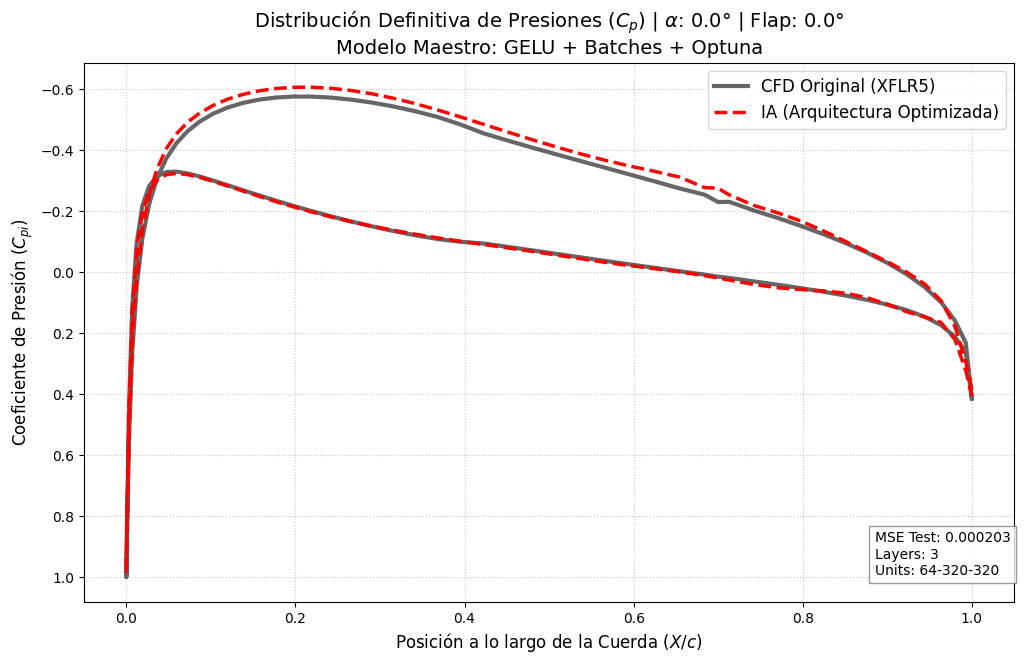

In [17]:
alfa_prueba = 0.0
delta_prueba = 0.0
reynolds_prueba = 900000.0

condicion = (df_dataset['Alpha'] == alfa_prueba) & \
            (df_dataset['Delta'] == delta_prueba) & \
            (df_dataset['Reynolds'] == reynolds_prueba)

datos_reales = df_dataset[condicion].sort_values(by='Point_Index')

if len(datos_reales) == 0:
    print(f"Aviso: No encontré simulaciones para Alpha={alfa_prueba} y Delta={delta_prueba}.")
else:
    X_real = datos_reales['X'].values
    Cpi_real = datos_reales['Cpi'].values
    
    entradas = datos_reales[['Reynolds', 'Delta', 'Alpha', 'X', 'Y']].values
    entradas_escaladas = scaler_X.transform(entradas)
    entradas_tensor = torch.FloatTensor(entradas_escaladas).to(device)
    
    modelo_final.eval()
    with torch.no_grad():
        prediccion_escalada = modelo_final(entradas_tensor).cpu().numpy()
        
    Cpi_predicho = scaler_y.inverse_transform(prediccion_escalada)
    
    # Configuración de la figura
    plt.figure(figsize=(12, 7))
    
    # Dibujamos CFD vs IA
    plt.plot(X_real, Cpi_real, 'k-', linewidth=3, alpha=0.6, label='CFD Original (XFLR5)')
    plt.plot(X_real, Cpi_predicho, 'r--', linewidth=2.5, label='IA (Arquitectura Optimizada)')
    
    plt.gca().invert_yaxis()
    plt.title(f'Distribución Definitiva de Presiones ($C_p$) | $\\alpha$: {alfa_prueba}° | Flap: {delta_prueba}°\nModelo Maestro: GELU + Batches + Optuna', fontsize=14)
    plt.xlabel('Posición a lo largo de la Cuerda ($X/c$)', fontsize=12)
    plt.ylabel('Coeficiente de Presión ($C_{pi}$)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Añadimos un pequeño cuadro de texto con la info
    info_text = f"MSE Test: {mse_test:.6f}\nLayers: 3\nUnits: 64-320-320"
    plt.text(0.85, 0.05, info_text, transform=plt.gca().transAxes, 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.show()

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import torch

# 1. Definir los regímenes de vuelo a testear
reynolds_fijo = 900000.0
casos_aerodinamicos = [
    {'Regimen': '1. Crucero', 'Alpha': 0.0, 'Delta': 0.0},
    {'Regimen': '2. Ascenso', 'Alpha': 10.0, 'Delta': 0.0},
    {'Regimen': '3. Aproximación', 'Alpha': 0.0, 'Delta': 15.0},
    {'Regimen': '4. Aterrizaje / Descenso', 'Alpha': 10.0, 'Delta': 15.0} 
]

# 2. Diccionario con la evolución de nuestros modelos
modelos_historia = {
    'V1: Baseline (ReLU)': modelo,
    'V2: Suavizado (GELU)': modelo_suave,
    'V3: Maestro (Optuna)': modelo_final
}

resultados = []

print("Evaluando modelos en diferentes regímenes aerodinámicos...\n")

for caso in casos_aerodinamicos:
    alfa = caso['Alpha']
    delta = caso['Delta']
    regimen = caso['Regimen']
    
    # Filtrado de los datos reales
    condicion = (df_dataset['Alpha'] == alfa) & \
                (df_dataset['Delta'] == delta) & \
                (df_dataset['Reynolds'] == reynolds_fijo)
                
    datos_reales = df_dataset[condicion].sort_values(by='Point_Index')
    
    if len(datos_reales) == 0:
        print(f"Salto el caso {regimen} porque no hay datos para Alpha={alfa}, Delta={delta}")
        continue
        
    Cpi_real = datos_reales['Cpi'].values
    entradas = datos_reales[['Reynolds', 'Delta', 'Alpha', 'X', 'Y']].values
    entradas_tensor = torch.FloatTensor(scaler_X.transform(entradas)).to(device)
    
    fila_resultado = {'Régimen de Vuelo': regimen, 'Alpha (°)': alfa, 'Flap (°)': delta}
    
    # Evaluación de cada modelo
    for nombre_modelo, mod in modelos_historia.items():
        mod.eval()
        with torch.no_grad():
            pred_escalada = mod(entradas_tensor).cpu().numpy()
            
        Cpi_predicho = scaler_y.inverse_transform(pred_escalada).flatten()
        mse_real = mean_squared_error(Cpi_real, Cpi_predicho)
        
        fila_resultado[nombre_modelo + ' (MSE x1000)'] = round(mse_real * 1000, 4)
        
    resultados.append(fila_resultado)

df_comparativa = pd.DataFrame(resultados)
print("TABLA COMPARATIVA DE RENDIMIENTO:")
display(df_comparativa)

Evaluando modelos en diferentes regímenes aerodinámicos...

TABLA COMPARATIVA DE RENDIMIENTO:


,Régimen de Vuelo,Alpha (°),Flap (°),V1: Baseline (ReLU) (MSE x1000),V2: Suavizado (GELU) (MSE x1000),V3: Maestro (Optuna) (MSE x1000)
0,1. Crucero,0.0,0.0,5.4637,2.5788,0.4368
1,2. Ascenso,10.0,0.0,4.4490,2.7276,1.1628
2,3. Aproximación,0.0,15.0,8.3923,5.9401,0.7521
3,4. Aterrizaje / Descenso,10.0,15.0,12.3956,6.7721,2.2827


Se puede apreciar como se ha conseguido una mejora en todas las fases del vuelo. Sin embargo, se puede ver cuales son más fáciles de aprender para la red:

- Crucero y aproximación: flujo suave y acoplado, no hay desprendimientos ni picos de succión. La red lo modela con facilidad.

- Ascenso y aterrizaje: el error es mayor, esto se debe a que la geometría está distorisionada por la deflexión del flap y el flujo es más turbulento y dificil de modelar.

Vemos el desempeño en todas las fases del vuelo de manera gráfica

<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4123/432639266.py:30: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title(f"{caso['Regimen']} ($\\alpha={alfa}^\circ$, $\delta={delta}^\circ$)", fontsize=12)
/tmp/ipykernel_4123/432639266.py:30: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title(f"{caso['Regimen']} ($\\alpha={alfa}^\circ$, $\delta={delta}^\circ$)", fontsize=12)


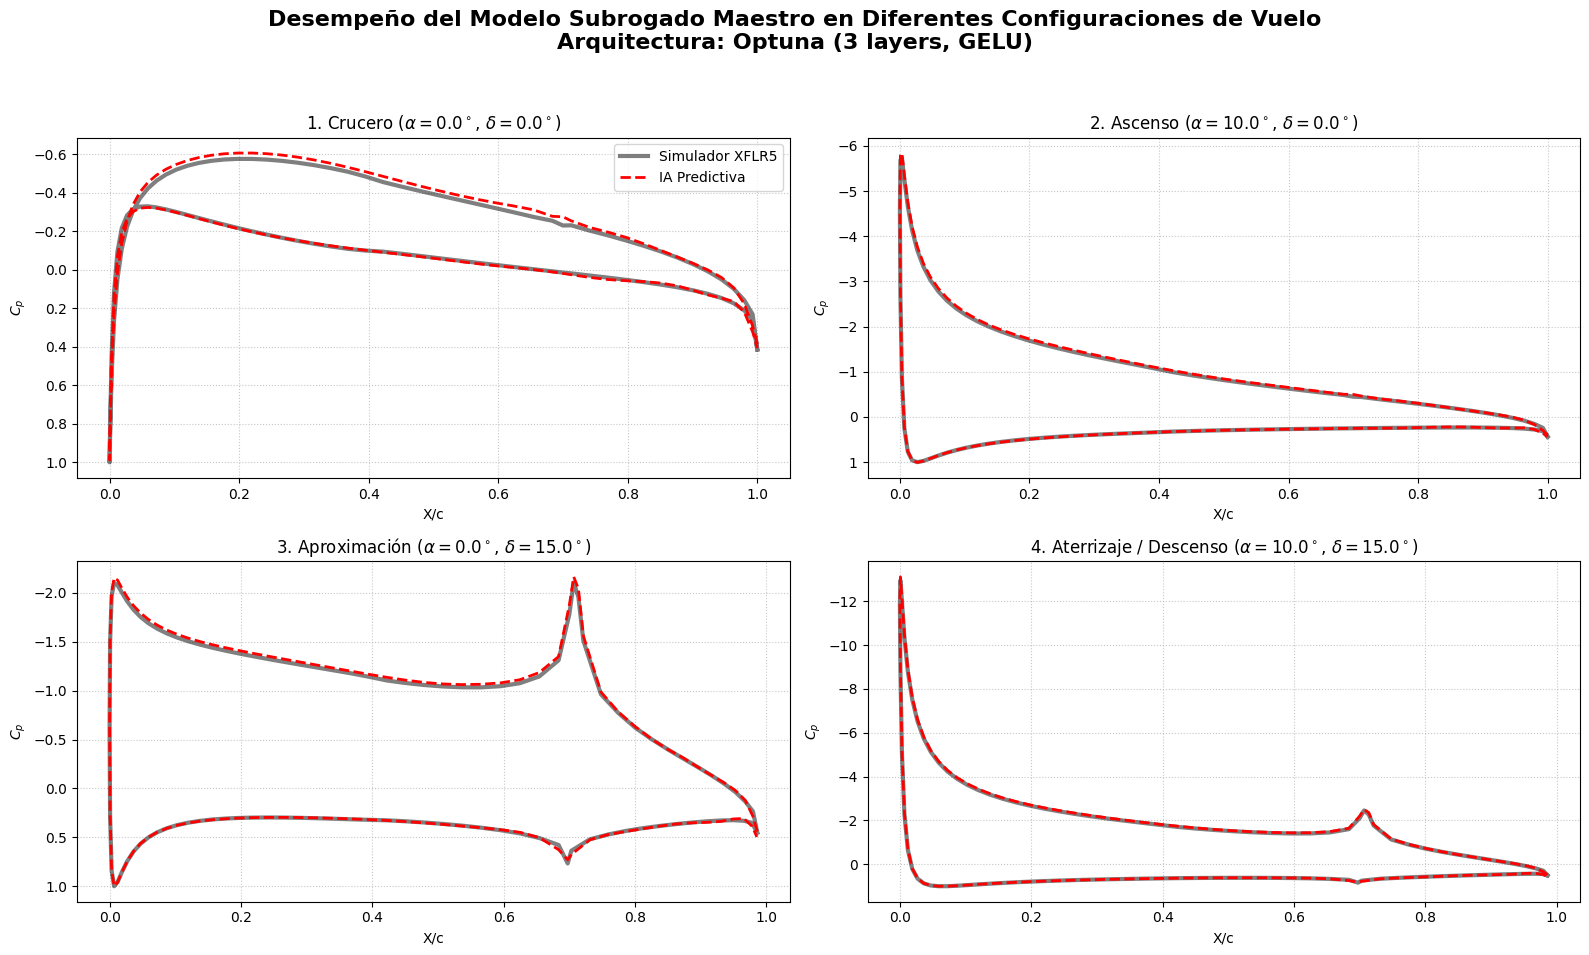

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Desempeño del Modelo Subrogado Maestro en Diferentes Configuraciones de Vuelo\nArquitectura: Optuna (3 layers, GELU)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, caso in enumerate(casos_aerodinamicos):
    if i >= 4: break # Solo mostramos 4 en este grid
    
    alfa, delta = caso['Alpha'], caso['Delta']
    
    condicion = (df_dataset['Alpha'] == alfa) & (df_dataset['Delta'] == delta) & (df_dataset['Reynolds'] == reynolds_fijo)
    datos_reales = df_dataset[condicion].sort_values(by='Point_Index')
    
    if len(datos_reales) > 0:
        X_real = datos_reales['X'].values
        Cpi_real = datos_reales['Cpi'].values
        
        entradas = datos_reales[['Reynolds', 'Delta', 'Alpha', 'X', 'Y']].values
        entradas_tensor = torch.FloatTensor(scaler_X.transform(entradas)).to(device)
        
        modelo_final.eval()
        with torch.no_grad():
            pred = modelo_final(entradas_tensor).cpu().numpy()
        Cpi_predicho = scaler_y.inverse_transform(pred)
        
        ax = axes[i]
        ax.plot(X_real, Cpi_real, 'k-', linewidth=3, alpha=0.5, label='Simulador XFLR5')
        ax.plot(X_real, Cpi_predicho, 'r--', linewidth=2, label='IA Predictiva')
        
        ax.invert_yaxis() # Aerodinámica requiere Y invertido
        ax.set_title(f"{caso['Regimen']} ($\\alpha={alfa}^\circ$, $\delta={delta}^\circ$)", fontsize=12)
        ax.set_xlabel('X/c')
        ax.set_ylabel('$C_p$')
        ax.grid(True, linestyle=':', alpha=0.7)
        if i == 0: ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Siguientes pasos:
- Implementar PINNS
- Modelar el campo viscoso mediante una red multi-salida
- Transicionar a una CNN o GNN
- Optimización de la forma del perfil